In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
pip install catboost

Bước 1: đọc file đưa vào dataframe

In [14]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier



from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

import datetime
import xgboost as xgb


import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE CNTT_BATBUOC_DAXULY ở bước 1 tiền xử lý --> đưa vào dataframe tên là df
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.1.TienXuLyDuLieu/lung_cancer_preprocessed.csv')

#in dữ liệu sau khi đọc từ file
print(df)

           AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0     0.682203       1        1                     1              1   
1     1.505110       1        1                     0              0   
2     0.049197       1        1                     0              0   
3    -0.837011       0        1                     0              1   
4     0.935405       0        1                     1              1   
...        ...     ...      ...                   ...            ...   
4995 -1.596618       0        1                     1              0   
4996  1.441810       0        1                     1              1   
4997 -0.393907       1        0                     0              1   
4998  1.188608       1        0                     1              0   
4999 -1.533317       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0      0.

In [15]:
# ===== Đổi tên cột PULMONARY_DISEASE -> target =====
df.rename(columns={'PULMONARY_DISEASE': 'target'}, inplace=True)

print(df)

           AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0     0.682203       1        1                     1              1   
1     1.505110       1        1                     0              0   
2     0.049197       1        1                     0              0   
3    -0.837011       0        1                     0              1   
4     0.935405       0        1                     1              1   
...        ...     ...      ...                   ...            ...   
4995 -1.596618       0        1                     1              0   
4996  1.441810       0        1                     1              1   
4997 -0.393907       1        0                     0              1   
4998  1.188608       1        0                     1              0   
4999 -1.533317       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0      0.

In [16]:
#kiem tra du lieu các cột còn thiếu giá trị (đếm các cột trống có dữ liệu trống)
df.isna().sum()

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


In [17]:
#cập nhật lại X, y
X = df.iloc[:, 0: -1]  # lấy tất cả các dòng, còn cột bỏ cột cuối
y = df.iloc[:, -1]  # chỉ lấy cột cuối

#hoặc viết
#X = df.drop(columns=['target'])
#y = df[['target']]


print(X)
print(y)

           AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0     0.682203       1        1                     1              1   
1     1.505110       1        1                     0              0   
2     0.049197       1        1                     0              0   
3    -0.837011       0        1                     0              1   
4     0.935405       0        1                     1              1   
...        ...     ...      ...                   ...            ...   
4995 -1.596618       0        1                     1              0   
4996  1.441810       0        1                     1              1   
4997 -0.393907       1        0                     0              1   
4998  1.188608       1        0                     1              0   
4999 -1.533317       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0      0.

Xây dựng model với các tham số vừa tìm được ở 1.2

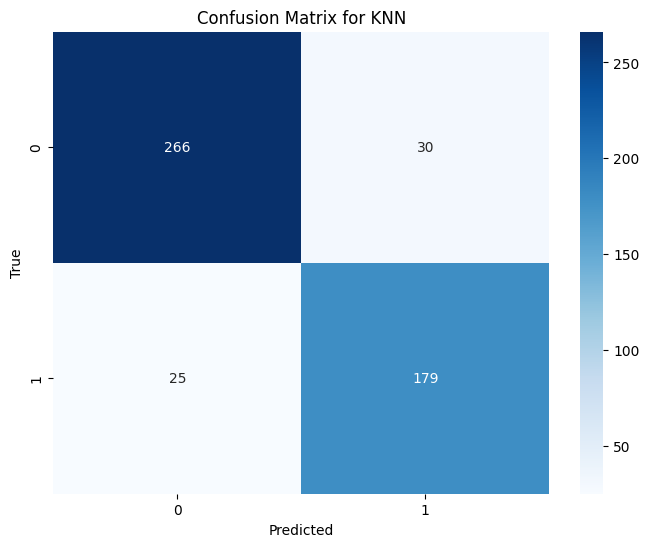

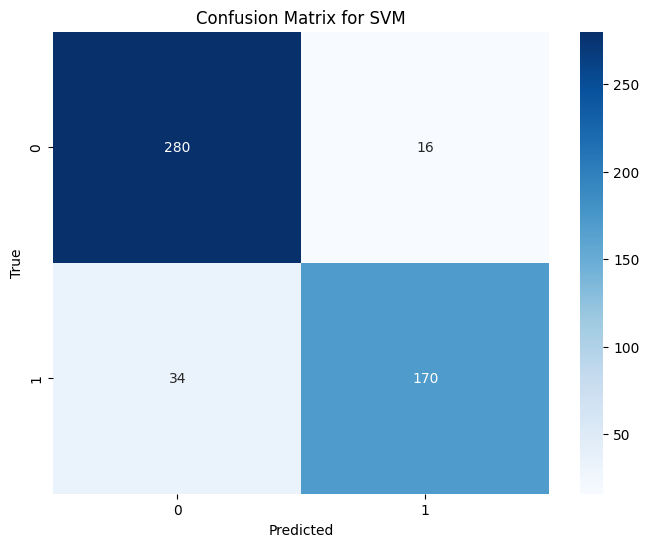

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

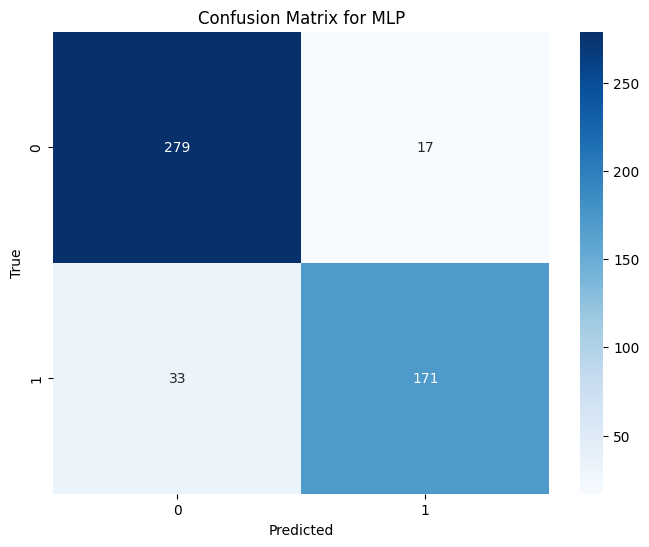

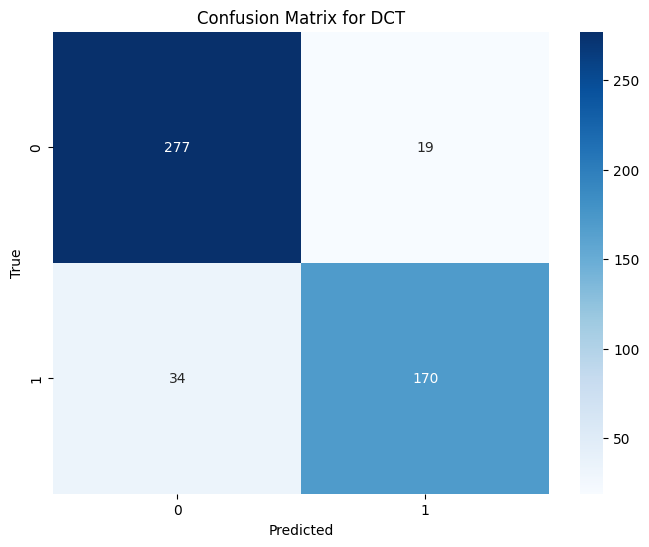

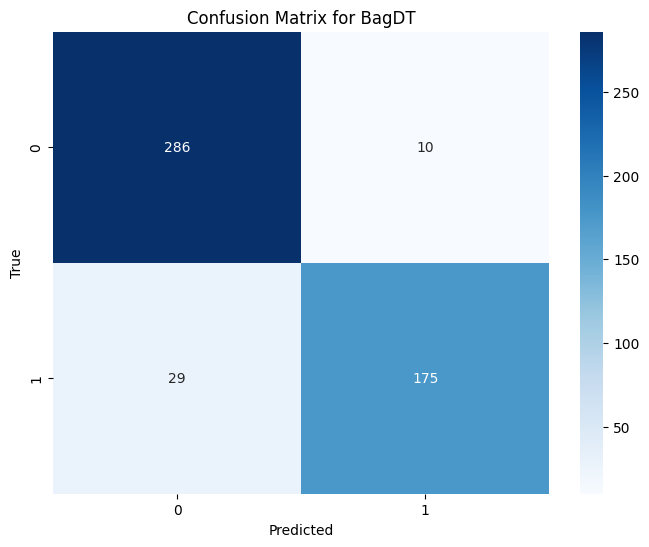

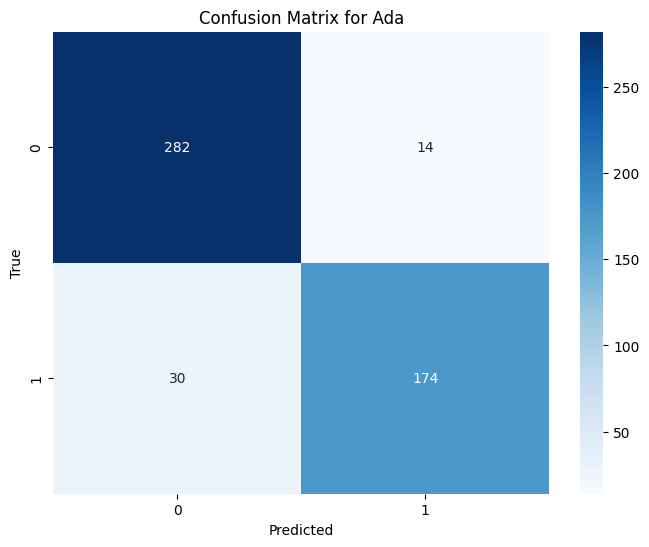

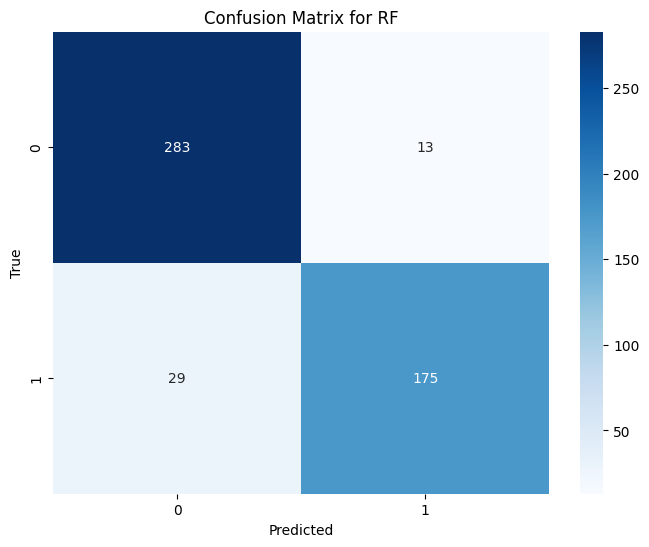

0:	learn: 0.6675769	total: 4.74ms	remaining: 469ms
1:	learn: 0.6436138	total: 7.74ms	remaining: 379ms
2:	learn: 0.6235279	total: 10.4ms	remaining: 336ms
3:	learn: 0.6017746	total: 13.3ms	remaining: 319ms
4:	learn: 0.5827565	total: 16.3ms	remaining: 309ms
5:	learn: 0.5658799	total: 19.2ms	remaining: 301ms
6:	learn: 0.5511277	total: 22.3ms	remaining: 297ms
7:	learn: 0.5354998	total: 25.3ms	remaining: 291ms
8:	learn: 0.5235467	total: 26.3ms	remaining: 266ms
9:	learn: 0.5099226	total: 29ms	remaining: 261ms
10:	learn: 0.4982377	total: 31.7ms	remaining: 256ms
11:	learn: 0.4854201	total: 34.3ms	remaining: 252ms
12:	learn: 0.4740566	total: 37ms	remaining: 247ms
13:	learn: 0.4648968	total: 39.8ms	remaining: 244ms
14:	learn: 0.4566366	total: 41.2ms	remaining: 233ms
15:	learn: 0.4471098	total: 43.9ms	remaining: 231ms
16:	learn: 0.4381724	total: 46.6ms	remaining: 227ms
17:	learn: 0.4300261	total: 49.2ms	remaining: 224ms
18:	learn: 0.4219747	total: 51.9ms	remaining: 221ms
19:	learn: 0.4151781	total

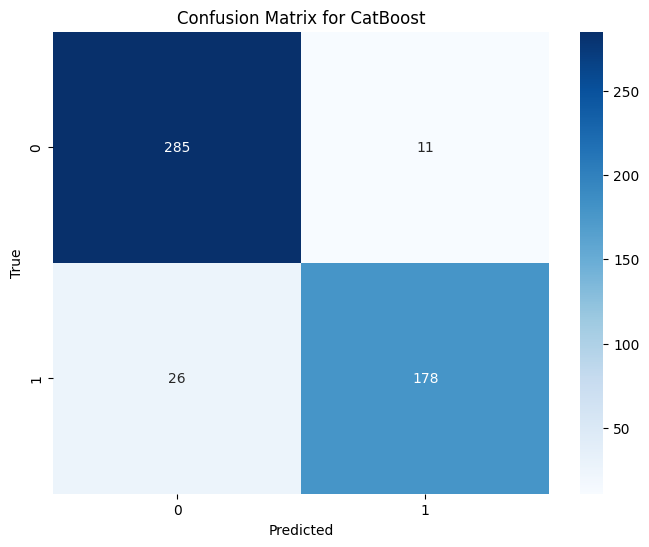

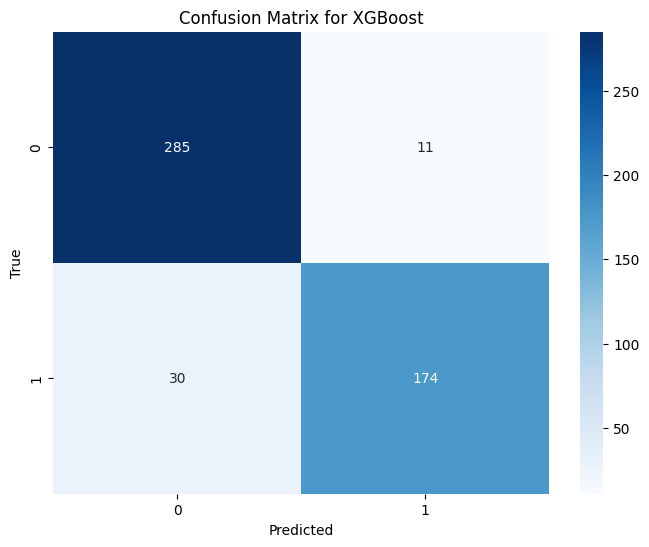

      Model  Accuracy  Precision  Recall  F1 Score  Training Time (s)
0       KNN     87.16   87.69202   87.16  87.23792            1.87082
1       SVM     89.56   89.57924   89.56  89.54652           57.43633
2       MLP     89.86   89.87569   89.86  89.84123           67.23888
3       DCT     90.04   90.04383   90.04  90.01987            0.43589
4     BagDT     91.24   91.25785   91.24  91.22473           65.60626
5       Ada     90.74   90.74469   90.74  90.72179           67.02037
6        RF     91.24   91.24368   91.24  91.22095           22.69645
7  CatBoost     91.40   91.40493   91.40  91.38433            3.41827
8   XGBoost     91.08   91.09356   91.08  91.06316            2.20369


In [18]:
# Khởi tạo các mô hình
knn = KNeighborsClassifier(n_neighbors=45, metric='manhattan', weights='distance')
svm = SVC(C=20, kernel='rbf', gamma='auto', probability=True)
decision_tree = DecisionTreeClassifier(max_depth=8, criterion='entropy',random_state=42)
random_forest = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
mlp = MLPClassifier(hidden_layer_sizes =(50,), max_iter = 500, random_state=42)
bagging = BaggingClassifier(decision_tree, n_estimators=300, bootstrap=True, random_state=42, n_jobs=8)
adaboost = AdaBoostClassifier(decision_tree, n_estimators = 200, learning_rate= 0.01, random_state=42)
catboost = CatBoostClassifier(iterations = 100, depth = 7, learning_rate = 0.05, random_state=42)
xgboost = XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42)

# Các giá trị và mô hình cần đánh giá
models = {
    'KNN': knn,
    'SVM': svm,
    'MLP': mlp,
    'DCT': decision_tree,
    'BagDT': bagging,
    'Ada': adaboost,
    'RF': random_forest,
    'CatBoost' : catboost,
    'XGBoost': xgboost
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Lưu kết quả đánh giá
evaluation_values = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Training Time (s)': []
}

# Chạy các mô hình và tính accuracy
for model_name, model in models.items():
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    start_time = time.time()

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)

        # đánh giá mô hình trên tập test
        y_pred = model.predict(X_test)

        # tính các chỉ số đánh giá
        accuracy = accuracy_score(y_test, y_pred)*100
        accuracy_scores.append(accuracy)

        precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)*100 # tính toán trên toàn bộ dữ liệu
        precision_scores.append(precision)

        recall = recall_score(y_test, y_pred, average='weighted')*100
        recall_scores.append(recall)

        f1 = f1_score(y_test, y_pred, average='weighted')*100
        f1_scores.append(f1)

        # Tính ma trận nhầm lẫn
        cm = confusion_matrix(y_test, y_pred)

    evaluation_values['Model'].append(model_name)

    mean_accuracy = round(np.mean(accuracy_scores),5)
    evaluation_values['Accuracy'].append(mean_accuracy)

    mean_precision = round(np.mean(precision_scores),5)
    evaluation_values['Precision'].append(mean_precision)

    mean_recall = round(np.mean(recall_scores),5)
    evaluation_values['Recall'].append(mean_recall)

    mean_f1_score = round(np.mean(f1_scores),5)
    evaluation_values['F1 Score'].append(mean_f1_score)

    end_time = time.time()  # Kết thúc đếm thời gian
    training_time = end_time - start_time
    evaluation_values['Training Time (s)'].append(round(training_time,5))

    # Vẽ ma trận nhầm lẫn
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/confusion_matrix_{model_name}.png')
    plt.show()

# Tạo DataFrame từ kết quả đánh giá
df_eval = pd.DataFrame(evaluation_values)

# Lưu DataFrame thành file csv
df_eval.to_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/KQ_Tong_Hop.csv', index=False)
# Lưu DataFrame thành file txt
output_file = "/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/KQ_Tong_Hop.txt"
with open(output_file, 'w') as txtfile:
    txtfile.write(df_eval.to_string(index=False))

# In kết quả
print(df_eval)

Vẽ đồ thị so sánh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


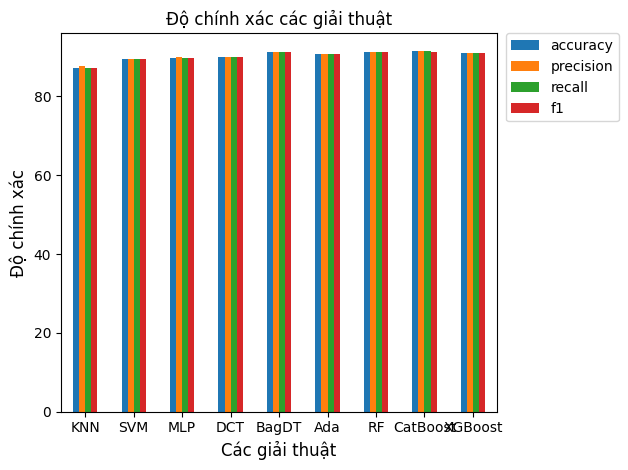

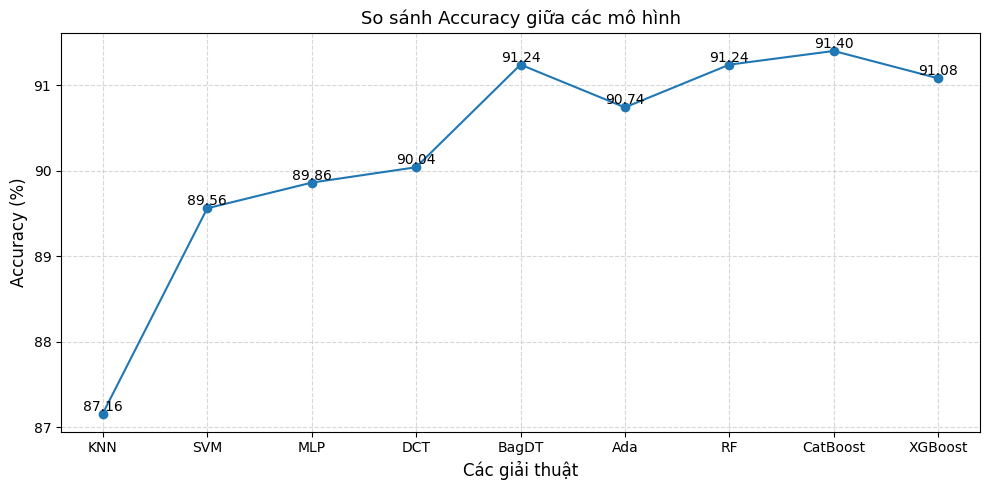

✔ Đã lưu: /content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/accuracy.png


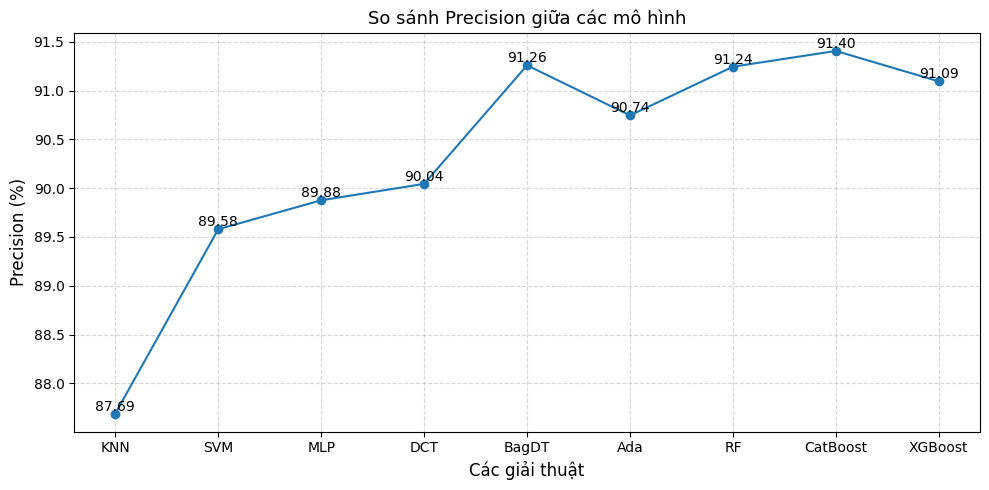

✔ Đã lưu: /content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/precision.png


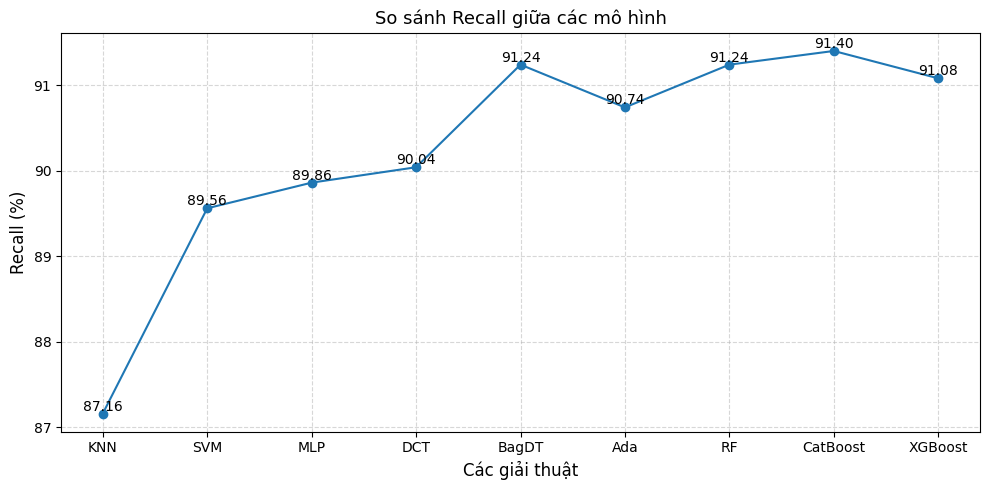

✔ Đã lưu: /content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/recall.png


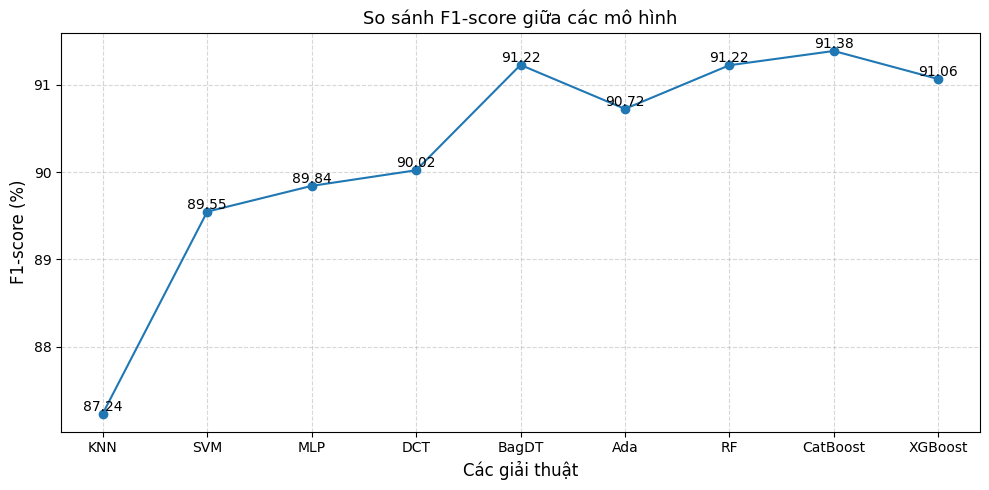

✔ Đã lưu: /content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/f1score.png


In [19]:
dt_models = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/KQ_Tong_Hop.csv')

model_names = dt_models['Model']
accuracy = dt_models['Accuracy'].tolist()
precision = dt_models['Precision'].tolist()
recall = dt_models['Recall'].tolist()
f1_score_raw = dt_models['F1 Score'].tolist()

# Thư mục lưu ảnh
save_path = "/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.3.XayDungModel/"

# ================== BIỂU ĐỒ CỘT ==================
dataframe1 = pd.DataFrame(
    {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1_score_raw
    },
    index=model_names
)

ax = dataframe1.plot.bar(rot=0, legend=True)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.set_xlabel("Các giải thuật", fontsize=12)
ax.set_ylabel("Độ chính xác", fontsize=12)
ax.set_title("Độ chính xác các giải thuật")

plt.tight_layout()
plt.savefig(save_path + "bieu_do_cot.png", dpi=300)
plt.show()

# ================== BIỂU ĐỒ ĐƯỜNG ==================
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score_raw
}

for metric_name, values in metrics.items():
    plt.figure(figsize=(10,5))
    plt.plot(model_names, values, marker='o')

    # Ghi giá trị lên từng điểm
    for i, v in enumerate(values):
        plt.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=10)

    plt.xlabel("Các giải thuật", fontsize=12)
    plt.ylabel(f"{metric_name} (%)", fontsize=12)
    plt.title(f"So sánh {metric_name} giữa các mô hình", fontsize=13)

    plt.xticks(rotation=0)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    file_name = save_path + f"{metric_name.replace('-', '').lower()}.png"
    plt.savefig(file_name, dpi=300)
    plt.show()

    print(f"✔ Đã lưu: {file_name}")